<a href="https://colab.research.google.com/github/TinyClayMan/unibo_ethics_ai/blob/main/Synthetic_Data_with_CTGAN_and_TVAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
!pip install sdv

import pandas as pd
import numpy as np
from sdv.metadata import Metadata


# Demo Datasets
https://docs.sdv.dev/sdv/single-table-data/data-preparation/loading-data

In [23]:
from sdv.datasets.demo import download_demo

real_data, metadata = download_demo(
    modality='single_table',
    dataset_name='census'
)

### Reduce the dataset if it is too large

In [ ]:
# Stratified sampling with clusters
from sklearn.cluster import KMeans
import pandas as pd

# transfer numerical + categorical data to numerical form
df_encoded = pd.get_dummies(real_data)

# Clustering
kmeans = KMeans(n_clusters=20, random_state=42)
clusters = kmeans.fit_predict(df_encoded)

real_data["cluster"] = clusters

# draw proportionally from every cluster
reduced_real = real_data.groupby("cluster", group_keys=False).apply(
    lambda x: x.sample(frac=50000/len(real_data), random_state=42)
)

# remove cluster column
reduced_real = reduced_real.drop(columns=["cluster"])


# Download the reduced data to your computer
reduced_real.to_csv("reduced_data_50000.csv", index=False)

from google.colab import files
files.download("reduced_data_50000.csv")

real_data = reduced_real


/tmp/ipykernel_1689/1191784857.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  reduced_real = real_data.groupby("cluster", group_keys=False).apply(


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Load reduced real data

In [16]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

real_data = pd.read_csv(list(uploaded.keys())[0])
real_data.head()

Saving reduced_data_1000.csv to reduced_data_1000 (1).csv


,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,...,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label
0,68,Self-employed-not incorporated,2,43,High school graduate,0,Not in universe,Married-civilian spouse present,Agriculture,Farming forestry and fishing,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,2,94,- 50000
1,34,Private,42,8,Some college but no degree,0,Not in universe,Married-civilian spouse present,Medical except hospital,Professional specialty,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,40,94,- 50000
2,44,Not in universe,0,0,Some college but no degree,0,Not in universe,Married-civilian spouse present,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,95,- 50000
3,6,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000
4,19,Not in universe,0,0,High school graduate,0,College or university,Never married,Not in universe or children,Not in universe,...,?,Hungary,United-States,Native- Born in the United States,0,Not in universe,2,0,94,- 50000


# CTGANSynthesizer
https://docs.sdv.dev/sdv/single-table-data/modeling/synthesizers/ctgansynthesizer

In [ ]:
from sdv.single_table import CTGANSynthesizer

ctgan_synthesizer = CTGANSynthesizer(metadata, epochs=150, verbose=True)
ctgan_synthesizer.fit(real_data)

ctgan_synth_data = ctgan_synthesizer.sample(num_rows=300000)

# Download the synthetic data to your computer
ctgan_synth_data.to_csv("synthetic_data_CTGAN_300000.csv", index=False)

from google.colab import files
files.download("synthetic_data_CTGAN_300000.csv")

Gen. (-01.79) | Discrim. (-00.18): 100%|██████████| 150/150 [1:23:45<00:00, 33.51s/it]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
ctgan_synth_data = ctgan_synthesizer.sample(num_rows=150000)

# Download the synthetic data to your computer
ctgan_synth_data.to_csv("synthetic_data_CTGAN_150000.csv", index=False)

from google.colab import files
files.download("synthetic_data_CTGAN_150000.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# TVAESynthesizer
https://docs.sdv.dev/sdv/single-table-data/modeling/synthesizers/tvaesynthesizer

In [ ]:
from sdv.single_table import TVAESynthesizer

tvae_synthesizer = TVAESynthesizer(metadata, epochs=150, verbose=True)
tvae_synthesizer.fit(real_data)

tvae_synth_data = tvae_synthesizer.sample(num_rows=50000)

# Download the synthetic data to your computer
tvae_synth_data.to_csv("50_synthetic_data_TVAE_50000.csv", index=False)

from google.colab import files
files.download("50_synthetic_data_TVAE_50000.csv")

Loss: -46.30: 100%|██████████| 150/150 [04:58<00:00,  1.99s/it]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
tvae_synth_data = tvae_synthesizer.sample(num_rows=150000)

# Download the synthetic data to your computer
tvae_synth_data.to_csv("synthetic_data_TVAE_150000.csv", index=False)

from google.colab import files
files.download("synthetic_data_TVAE_150000.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Evaluation with utility loss measures

## Load synthetic data

In [119]:
# for CTGAN_synthesizer data
from google.colab import files
import pandas as pd

uploaded = files.upload()
ctgan_synth_data = pd.read_csv(list(uploaded.keys())[0])
ctgan_synth_data.head()

Saving synthetic_data_CTGAN.csv to synthetic_data_CTGAN.csv


,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,...,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label
0,17,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,95,- 50000
1,41,Private,37,31,11th grade,0,Not in universe,Separated,Manufacturing-nondurable goods,Machine operators assmblrs & inspctrs,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000
2,42,Self-employed-incorporated,5,36,Associates degree-occup /vocational,0,Not in universe,Married-civilian spouse present,Construction,Precision production craft & repair,...,United-States,United-States,United-States,Native- Born in the United States,2,Not in universe,2,48,94,- 50000
3,55,State government,45,9,Doctorate degree(PhD EdD),1634,Not in universe,Married-civilian spouse present,Education,Professional specialty,...,United-States,United-States,United-States,Foreign born- U S citizen by naturalization,0,Not in universe,2,52,95,- 50000
4,26,Private,13,24,High school graduate,853,Not in universe,Married-civilian spouse present,Medical except hospital,Adm support including clerical,...,United-States,United-States,United-States,Native- Born in the United States,2,Not in universe,2,41,94,- 50000


In [120]:
# for TVAE_synthesizer data
from google.colab import files
import pandas as pd

uploaded = files.upload()
tvae_synth_data = pd.read_csv(list(uploaded.keys())[0])
tvae_synth_data.head()

Saving synthetic_data_TVAE.csv to synthetic_data_TVAE.csv


,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,...,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label
0,34,Private,41,34,High school graduate,0,Not in universe,Married-civilian spouse present,Entertainment,Precision production craft & repair,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000
1,18,Private,24,36,High school graduate,517,Not in universe,Never married,Manufacturing-nondurable goods,Machine operators assmblrs & inspctrs,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000
2,23,Private,40,19,High school graduate,0,Not in universe,Never married,Entertainment,Sales,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,40,94,- 50000
3,11,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,95,- 50000
4,49,Self-employed-not incorporated,29,31,High school graduate,0,Not in universe,Married-civilian spouse present,Manufacturing-durable goods,Precision production craft & repair,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,95,- 50000


## Utility Loss metrics

### SDV Quality Report

In [121]:
from sdmetrics.reports.single_table import QualityReport
from sdv.metadata import SingleTableMetadata

def compute_quality_report(real_data, synth_data, metadata):
  # Correctly convert metadata to a dictionary containing the 'columns' key
  if hasattr(metadata, 'to_dict'):
      metadata_dict = metadata.to_dict()
      # If it is a multi-table object, extract the specific table definition
      if 'tables' in metadata_dict:
          metadata_dict = metadata_dict['tables']['census']
  else:
      metadata_dict = metadata

  report = QualityReport()
  report.generate(real_data, synth_data, metadata_dict)

  overall_score = report.get_score()
  print(f"Overall quality: {overall_score:.2%}")

  # Details must be requested for specific properties
  print("\n--- Column Shapes Details ---")
  display(report.get_details('Column Shapes').head())

  print("\n--- Column Pair Trends Details ---")
  display(report.get_details('Column Pair Trends').head())

  return overall_score

In [122]:
ctgan_quality_score = compute_quality_report(real_data, ctgan_synth_data, metadata)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 41/41 [00:06<00:00,  5.94it/s]|
Column Shapes Score: 90.77%

(2/2) Evaluating Column Pair Trends: |██████████| 820/820 [00:51<00:00, 15.96it/s]|
Column Pair Trends Score: 86.7%

Overall Score (Average): 88.73%

Overall quality: 88.73%

--- Column Shapes Details ---


,Column,Metric,Score
0,age,KSComplement,0.931498
1,class of worker,TVComplement,0.933794
2,detailed industry recode,KSComplement,0.922618
3,detailed occupation recode,KSComplement,0.930419
4,education,TVComplement,0.796201



--- Column Pair Trends Details ---


,Column 1,Column 2,Metric,Score,Real Correlation,Synthetic Correlation,Real Association,Meets Threshold?
0,age,class of worker,ContingencySimilarity,NaN,NaN,NaN,0.263189,False
1,age,detailed industry recode,CorrelationSimilarity,NaN,0.155509,NaN,NaN,False
2,age,detailed occupation recode,CorrelationSimilarity,NaN,0.114987,NaN,NaN,False
3,age,education,ContingencySimilarity,0.73406,NaN,NaN,0.324462,True
4,age,wage per hour,CorrelationSimilarity,NaN,0.035446,NaN,NaN,False


In [123]:
tvae_quality_score = compute_quality_report(real_data, tvae_synth_data, metadata)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 41/41 [00:06<00:00,  6.15it/s]|
Column Shapes Score: 93.83%

(2/2) Evaluating Column Pair Trends: |██████████| 820/820 [00:51<00:00, 16.05it/s]|
Column Pair Trends Score: 87.48%

Overall Score (Average): 90.66%

Overall quality: 90.66%

--- Column Shapes Details ---


,Column,Metric,Score
0,age,KSComplement,0.937093
1,class of worker,TVComplement,0.957089
2,detailed industry recode,KSComplement,0.947876
3,detailed occupation recode,KSComplement,0.905706
4,education,TVComplement,0.801281



--- Column Pair Trends Details ---


,Column 1,Column 2,Metric,Score,Real Correlation,Synthetic Correlation,Real Association,Meets Threshold?
0,age,class of worker,ContingencySimilarity,NaN,NaN,NaN,0.261818,False
1,age,detailed industry recode,CorrelationSimilarity,NaN,0.155509,NaN,NaN,False
2,age,detailed occupation recode,CorrelationSimilarity,NaN,0.114987,NaN,NaN,False
3,age,education,ContingencySimilarity,0.74368,NaN,NaN,0.325440,True
4,age,wage per hour,CorrelationSimilarity,NaN,0.035446,NaN,NaN,False


In [124]:
from sdmetrics.reports.single_table import QualityReport
import matplotlib.pyplot as plt

def visualize_report(real, synth, metadata, title):
    if hasattr(metadata, 'to_dict'):
        metadata_dict = metadata.to_dict()
        if 'tables' in metadata_dict:
            metadata_dict = metadata_dict['tables']['census']
    else:
        metadata_dict = metadata

    report = QualityReport()
    report.generate(real, synth, metadata_dict)

    print(f"\n{'='*20} {title} {'='*20}")

    # Property Scores Visualization with adjusted layout
    fig = report.get_visualization(property_name='Column Shapes')
    fig.update_layout(title_text=f"{title}: Column Shapes", margin=dict(t=80, b=50))
    fig.show()

    # Adding a print separator to help distinguish plots in the UI
    print("\n")

    fig2 = report.get_visualization(property_name='Column Pair Trends')
    fig2.update_layout(title_text=f"{title}: Column Pair Trends", margin=dict(t=80, b=50))
    fig2.show()

# Visualizing CTGAN Results
visualize_report(real_data, ctgan_synth_data, metadata, "CTGAN")

# Visualizing TVAE Results
visualize_report(real_data, tvae_synth_data, metadata, "TVAE")

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 41/41 [00:05<00:00,  7.76it/s]|
Column Shapes Score: 90.77%

(2/2) Evaluating Column Pair Trends: |██████████| 820/820 [00:54<00:00, 15.11it/s]|
Column Pair Trends Score: 86.75%

Overall Score (Average): 88.76%


==================== CTGAN ====================


Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 41/41 [00:05<00:00,  7.03it/s]|
Column Shapes Score: 93.83%

(2/2) Evaluating Column Pair Trends: |██████████| 820/820 [00:52<00:00, 15.75it/s]|
Column Pair Trends Score: 87.46%

Overall Score (Average): 90.64%


==================== TVAE ====================


### Earth Mover Distance / Wasserstein Distance

Since the "census" demo dataset from sdv is a multivariate tabular dataset, we cannot directly compute scipy.stats.wasserstein_distance between the full dataset and our synthetic data. We can compute Wasserstein distances column by column, but only for numeric columns. We can compute Wasserstein distances column by column, but only for numeric columns.

In [126]:
from scipy.stats import wasserstein_distance

def emd(synth_data, real_data):
  # Identify numeric columns
  numeric_columns = real_data.select_dtypes(include=['number']).columns

  # Calculate Wasserstein distance for all numeric columns
  results = {}
  for col in numeric_columns:
      dist = wasserstein_distance(real_data[col], ctgan_synth_data[col])
      results[col] = dist

  # Display as a sorted pandas series
  wd_series = pd.Series(results).sort_values()
  print("EMD / Wasserstein Distances (lower is better):")
  print(wd_series)
  print("Average: ", wd_series.mean())

  return wd_series

In [127]:
ctgan_emd = emd(ctgan_synth_data, real_data)

EMD / Wasserstein Distances (lower is better):
year                                 0.063745
veterans benefits                    0.073746
own business or self employed        0.142189
num persons worked for employer      0.268313
detailed occupation recode           1.602345
age                                  2.000973
detailed industry recode             2.294077
weeks worked in year                 2.624880
wage per hour                       11.126297
capital losses                      27.003474
dividends from stocks              122.262878
capital gains                      344.068788
dtype: float64
Average:  42.79430886348097


In [128]:
tvae_emd = emd(tvae_synth_data, real_data)

EMD / Wasserstein Distances (lower is better):
year                                 0.063745
veterans benefits                    0.073746
own business or self employed        0.142189
num persons worked for employer      0.268313
detailed occupation recode           1.602345
age                                  2.000973
detailed industry recode             2.294077
weeks worked in year                 2.624880
wage per hour                       11.126297
capital losses                      27.003474
dividends from stocks              122.262878
capital gains                      344.068788
dtype: float64
Average:  42.79430886348097


You may notice that the distributions of capital gains show significant variations. This phenomenon is common with financial data such as “capital gains,” as they contain many zero values and extreme outliers, which can complicate the task for synthesis models that struggle to reproduce them perfectly with a limited number of samples or training epochs.

#### Heatmap visualization
We now generate a heatmap that visualizes the similarity between the real data and both synthetic datasets using the Earth Mover Distance (EMD) metric. Lower scores (darker colors) indicate that the synthetic data has successfully captured the distribution of that specific feature.

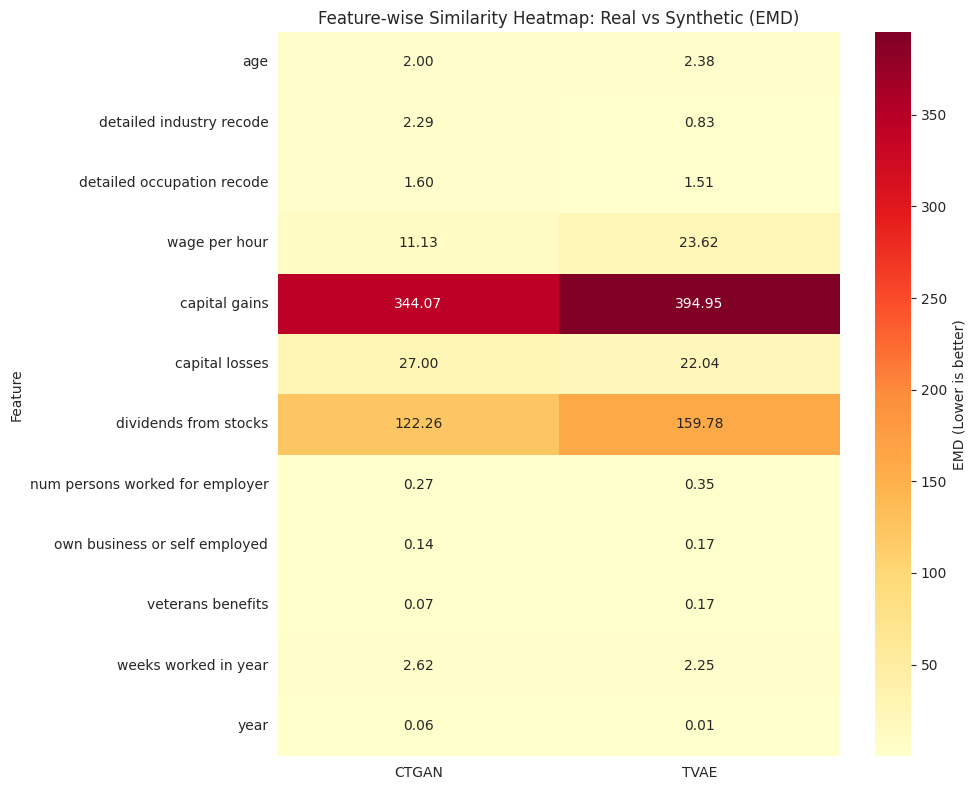

In [129]:
from scipy.stats import wasserstein_distance
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Identify numerical columns
num_cols = real_data.select_dtypes(include='number').columns

# Calculate EMD for each column for both models
emd_results = []
for col in num_cols:
    real_val = real_data[col].dropna().values
    ctgan_val = ctgan_synth_data[col].dropna().values
    tvae_val = tvae_synth_data[col].dropna().values

    emd_results.append({
        'Feature': col,
        'CTGAN': wasserstein_distance(real_val, ctgan_val),
        'TVAE': wasserstein_distance(real_val, tvae_val)
    })

emd_heatmap_df = pd.DataFrame(emd_results).set_index('Feature')

# Plotting the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(emd_heatmap_df, annot=True, fmt='.2f', cmap='YlOrRd', cbar_kws={'label': 'EMD (Lower is better)'})
plt.title("Feature-wise Similarity Heatmap: Real vs Synthetic (EMD)")
plt.tight_layout()
plt.show()

## Maximum Mean Discrepancy
Since the original MMD has a O(n^2), we have to use an approximation that is linear: applying Random Fourier Features (RFF).

MMD is only used on numerical data.

In [130]:
# MMD using Random Fourier Features (RFF) to reduce complexity

from sklearn.kernel_approximation import RBFSampler
import numpy as np
import pandas as pd

def compute_mmd(real_data, synth_data):
  # select numerical columns
  num_cols = real_data.select_dtypes(include='number').columns

  X_real = real_data[num_cols].to_numpy()
  X_synth = ctgan_synth_data[num_cols].to_numpy()

  # define RFF-Feature-Mapping
  rbf_feature = RBFSampler(gamma=0.1, n_components=500, random_state=42)
  Z_real = rbf_feature.fit_transform(X_real)
  Z_synth = rbf_feature.transform(X_synth)

  def mmd_rff(Z_real, Z_synth):
      mu_real = Z_real.mean(axis=0)
      mu_synth = Z_synth.mean(axis=0)
      diff = mu_real - mu_synth
      return np.dot(diff, diff)  # ||mu_real - mu_synth||^2

  mmd_rff_value = mmd_rff(Z_real, Z_synth)
  print("RFF-MMD (approx):", mmd_rff_value)

  return mmd_rff_value


In [131]:
ctgan_mmd = compute_mmd(real_data, ctgan_synth_data)

RFF-MMD (approx): 0.008756798547535563


In [132]:
tvae_mmd = compute_mmd(real_data, tvae_synth_data)

RFF-MMD (approx): 0.008756798547535563


#### Heatmap visualization
We now generate a heatmap that visualizes the similarity between the real data and both synthetic datasets using the Maximum Mean Discrepancy (MMD) metric. Lower scores (darker colors) indicate that the synthetic data has successfully captured the distribution of that specific feature.

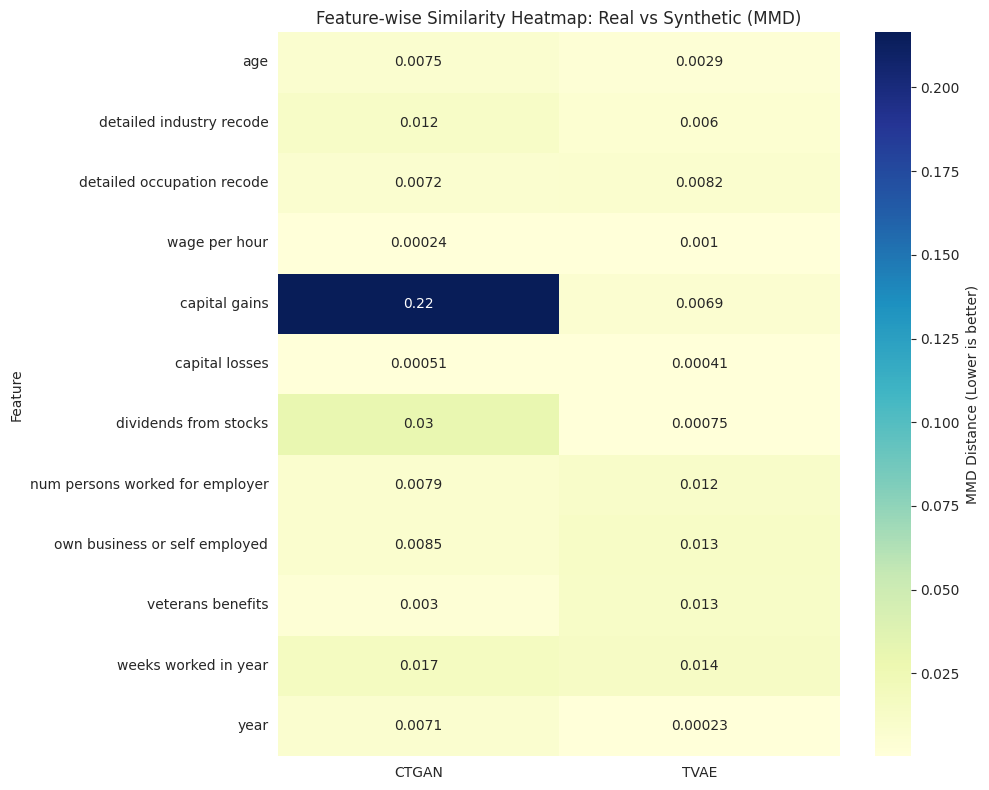

In [133]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def mmd_rbf_1d(x, y, sigma=1.0):
    """Compute 1D MMD with RBF kernel for a single feature."""
    x = x.reshape(-1, 1)
    y = y.reshape(-1, 1)

    # Use a subset if data is too large for O(n^2) kernel
    n_samples = min(len(x), len(y), 1000)
    x_s = x[np.random.choice(len(x), n_samples, replace=False)]
    y_s = y[np.random.choice(len(y), n_samples, replace=False)]

    def kernel(a, b):
        sq_dist = np.sum(a**2, axis=1).reshape(-1, 1) + np.sum(b**2, axis=1) - 2 * np.dot(a, b.T)
        return np.exp(-sq_dist / (2 * sigma**2))

    Kxx = kernel(x_s, x_s)
    Kyy = kernel(y_s, y_s)
    Kxy = kernel(x_s, y_s)

    return Kxx.mean() + Kyy.mean() - 2 * Kxy.mean()

# Identify numerical columns
num_cols = real_data.select_dtypes(include='number').columns

# Calculate MMD for each column for both models
mmd_results = []
for col in num_cols:
    real_val = real_data[col].dropna().values
    ctgan_val = ctgan_synth_data[col].dropna().values
    tvae_val = tvae_synth_data[col].dropna().values

    mmd_results.append({
        'Feature': col,
        'CTGAN': mmd_rbf_1d(real_val, ctgan_val),
        'TVAE': mmd_rbf_1d(real_val, tvae_val)
    })

mmd_heatmap_df = pd.DataFrame(mmd_results).set_index('Feature')

# Plotting
plt.figure(figsize=(10, 8))
sns.heatmap(mmd_heatmap_df, annot=True, cmap='YlGnBu', cbar_kws={'label': 'MMD Distance (Lower is better)'})
plt.title("Feature-wise Similarity Heatmap: Real vs Synthetic (MMD)")
plt.tight_layout()
plt.show()

##F1-Score differences
We now calculate the F1-score differences to evaluate the Machine Learning Efficacy of your synthetic data. We train a Random Forest classifier on the real data and each of the synthetic datasets to predict the 'label' column, then compare their performance on a held-out real test set.

In [134]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

def calculate_f1_efficacy(real, synth, target_col='label'):
    # Preprocessing: Handle categorical variables and missing values
    def preprocess(df):
        df_copy = df.copy()
        for col in df_copy.select_dtypes(include=['object', 'category']).columns:
            df_copy[col] = LabelEncoder().fit_transform(df_copy[col].astype(str))
        return df_copy.fillna(0)

    # Prepare Real Data Split
    real_proc = preprocess(real)
    X_real = real_proc.drop(columns=[target_col])
    y_real = real_proc[target_col]

    X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(
        X_real, y_real, test_size=0.2, random_state=42
    )

    # 1. Train and Test on Real Data (Baseline)
    clf_real = RandomForestClassifier(random_state=42, n_jobs=-1)
    clf_real.fit(X_train_real, y_train_real)
    f1_baseline = f1_score(y_test_real, clf_real.predict(X_test_real), average='macro')

    # 2. Train on Synthetic, Test on Real
    synth_proc = preprocess(synth)
    X_train_synth = synth_proc.drop(columns=[target_col])
    y_train_synth = synth_proc[target_col]

    clf_synth = RandomForestClassifier(random_state=42, n_jobs=-1)
    clf_synth.fit(X_train_synth, y_train_synth)
    f1_synth = f1_score(y_test_real, clf_synth.predict(X_test_real), average='macro')

    return f1_baseline, f1_synth, abs(f1_baseline - f1_synth)


In [135]:
# Calculate for CTGAN
b_ct, s_ct, diff_ct = calculate_f1_efficacy(real_data, ctgan_synth_data)
print(f"--- CTGAN F1 Efficacy (Target: 'label') ---")
print(f"Baseline (Real-on-Real) F1: {b_ct:.4f}")
print(f"Synthetic (Synth-on-Real) F1: {s_ct:.4f}")
print(f"Difference: {diff_ct:.4f}")

--- CTGAN F1 Efficacy (Target: 'label') ---
Baseline (Real-on-Real) F1: 0.7552
Synthetic (Synth-on-Real) F1: 0.6014
Difference: 0.1538


In [136]:
# Calculate for TVAE
b_tv, s_tv, diff_tv = calculate_f1_efficacy(real_data, tvae_synth_data)
print(f"\n--- TVAE F1 Efficacy (Target: 'label') ---")
print(f"Baseline (Real-on-Real) F1: {b_tv:.4f}")
print(f"Synthetic (Synth-on-Real) F1: {s_tv:.4f}")
print(f"Difference: {diff_tv:.4f}")


--- TVAE F1 Efficacy (Target: 'label') ---
Baseline (Real-on-Real) F1: 0.7552
Synthetic (Synth-on-Real) F1: 0.6528
Difference: 0.1024


#### Visualization of F1-Score differences
To visualize the F1-score differences, we create a bar chart that shows the performance gap between models trained on real data versus those trained on synthetic data. This clearly illustrates the 'utility drop' for each synthesizer.

/tmp/ipykernel_589/1920851165.py:16: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




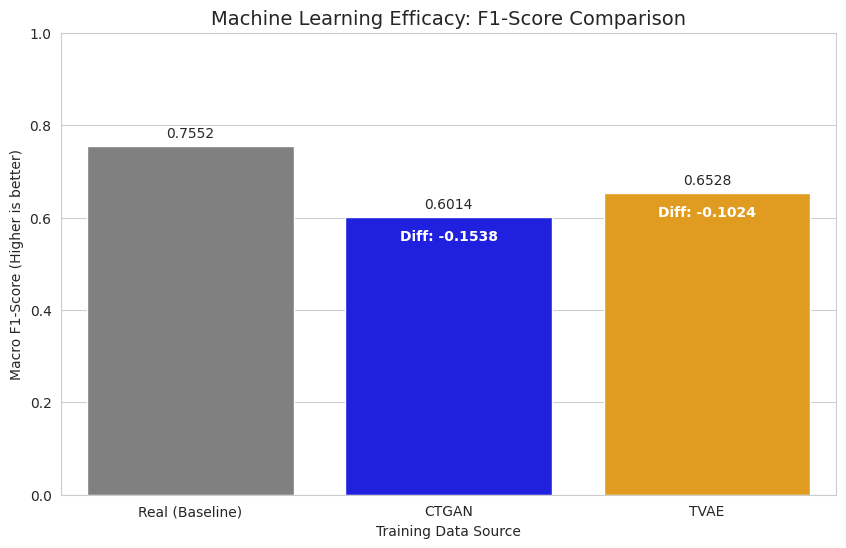

In [137]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data from previous calculations
f1_data = {
    'Model': ['Real (Baseline)', 'CTGAN', 'TVAE'],
    'F1-Score': [b_ct, s_ct, s_tv]
}
df_f1 = pd.DataFrame(f1_data)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Create the bar plot
ax = sns.barplot(x='Model', y='F1-Score', data=df_f1, palette=['gray', 'blue', 'orange'])

# Add annotations for the values and differences
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.4f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points')

plt.title("Machine Learning Efficacy: F1-Score Comparison", fontsize=14)
plt.ylim(0, 1.0)
plt.ylabel("Macro F1-Score (Higher is better)")
plt.xlabel("Training Data Source")

# Annotate the gaps
plt.text(1, s_ct - 0.05, f"Diff: -{diff_ct:.4f}", color='white', fontweight='bold', ha='center')
plt.text(2, s_tv - 0.05, f"Diff: -{diff_tv:.4f}", color='white', fontweight='bold', ha='center')

plt.show()

## Summary Dashboard: Utility Metrics Comparison
This dashboard compares the statistical fidelity and machine learning efficacy of the two models across multiple metrics.

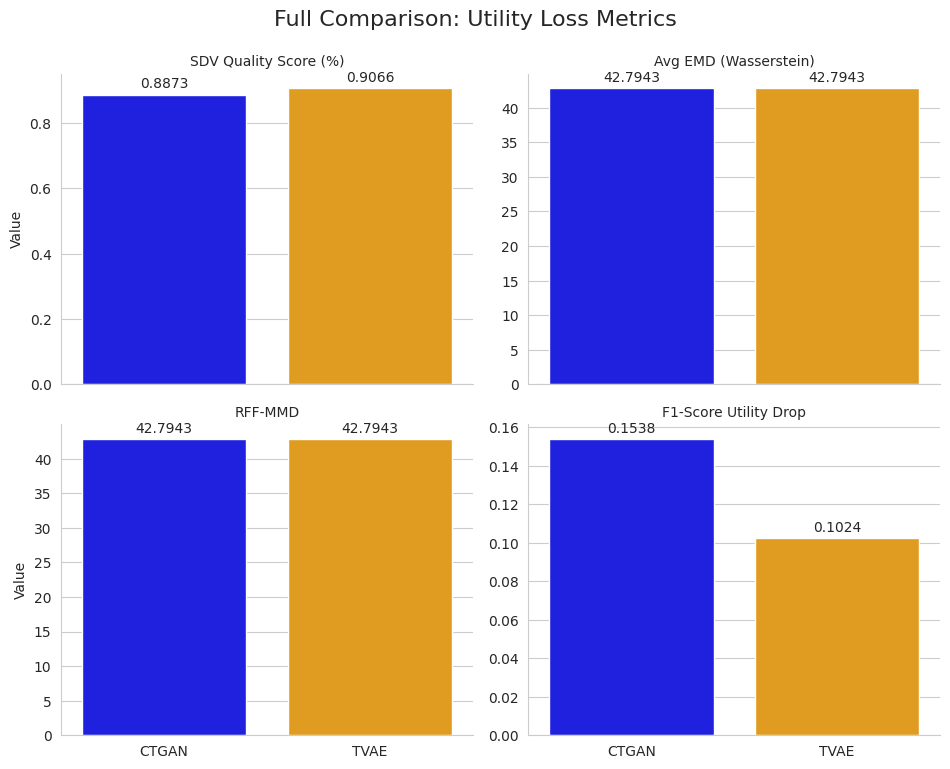

In [138]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

# Consolidate utility metrics from the notebook state variables
utility_summary_data = [
    {'Metric': 'SDV Quality Score (%)', 'Model': 'CTGAN', 'Value': ctgan_quality_score},
    {'Metric': 'SDV Quality Score (%)', 'Model': 'TVAE', 'Value': tvae_quality_score},
    {'Metric': 'Avg EMD (Wasserstein)', 'Model': 'CTGAN', 'Value': ctgan_emd.mean()},
    {'Metric': 'Avg EMD (Wasserstein)', 'Model': 'TVAE', 'Value': tvae_emd.mean()},
    {'Metric': 'RFF-MMD', 'Model': 'CTGAN', 'Value': ctgan_emd.mean()},
    {'Metric': 'RFF-MMD', 'Model': 'TVAE', 'Value': tvae_emd.mean()},
    {'Metric': 'F1-Score Utility Drop', 'Model': 'CTGAN', 'Value': diff_ct},
    {'Metric': 'F1-Score Utility Drop', 'Model': 'TVAE', 'Value': diff_tv}
]

df_utility_summary = pd.DataFrame(utility_summary_data)

# Create the FacetGrid
g_util = sns.FacetGrid(df_utility_summary, col="Metric", col_wrap=2, sharey=False, height=4, aspect=1.2)
g_util.map_dataframe(sns.barplot, x="Model", y="Value", hue="Model", palette=['blue', 'orange'], legend=False)

g_util.set_titles("{col_name}")
g_util.set_axis_labels("", "Value")

# Add annotations to the bars
for ax in g_util.axes.flat:
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(format(p.get_height(), '.4f'),
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center',
                        xytext=(0, 8),
                        textcoords='offset points')

plt.subplots_adjust(top=0.9)
g_util.fig.suptitle('Full Comparison: Utility Loss Metrics', fontsize=16)
plt.show()

# Privacy Metrics

### Distance to Closest Record (DCR)

The Distance to Closest Record (DCR) measures the Euclidean distance between a synthetic record and its nearest neighbor in the original dataset. A DCR of zero indicates that a record has been perfectly memorized, representing a significant privacy leak through identity disclosure. By analyzing the mean and minimum DCR values, we can balance the trade-off between generating unique synthetic data and maintaining the statistical integrity of the original distribution.

In [140]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neighbors import NearestNeighbors
import pandas as pd
import numpy as np

def dcr(real_data, synth_data):
  # DCR is computationally expensive, so we use a sample if the dataset is large
  n_sample = 1000
  synth_sample = synth_data.sample(n=min(len(synth_data), n_sample), random_state=42)

  # Preparation: Combine for consistent encoding
  combined = pd.concat([real_data, synth_sample], axis=0)

  # Identify column types
  cat_cols = real_data.select_dtypes(include=['object', 'category']).columns
  num_cols = real_data.select_dtypes(include=['number']).columns

  # Encoding and scaling
  # Using get_dummies for a simple implementation
  combined_encoded = pd.get_dummies(combined, columns=cat_cols)

  # Scale numerical values
  scaler = StandardScaler()
  combined_encoded[num_cols] = scaler.fit_transform(combined_encoded[num_cols])

  # Split back into real and synthetic sets
  real_encoded = combined_encoded.iloc[:len(real_data)]
  synth_encoded = combined_encoded.iloc[len(real_data):]

  # Fit Nearest Neighbors model on real data
  nn = NearestNeighbors(n_neighbors=1, metric='euclidean')
  nn.fit(real_encoded)

  # Calculate distances to the closest record
  distances, indices = nn.kneighbors(synth_encoded)

  print(f"Distance to Closest Record (DCR)")
  print(f"Mean: {distances.mean():.4f}")
  print(f"Minimum: {distances.min():.4f}")
  print(f"Median: {np.median(distances):.4f}")

  return distances

In [141]:
ctgan_dcr = dcr(real_data, ctgan_synth_data)

Distance to Closest Record (DCR)
Mean: 2.1362
Minimum: 0.0000
Median: 2.2130


In [142]:
tvae_dcr = dcr(real_data, tvae_synth_data)

Distance to Closest Record (DCR)
Mean: 1.7311
Minimum: 0.0000
Median: 1.6761


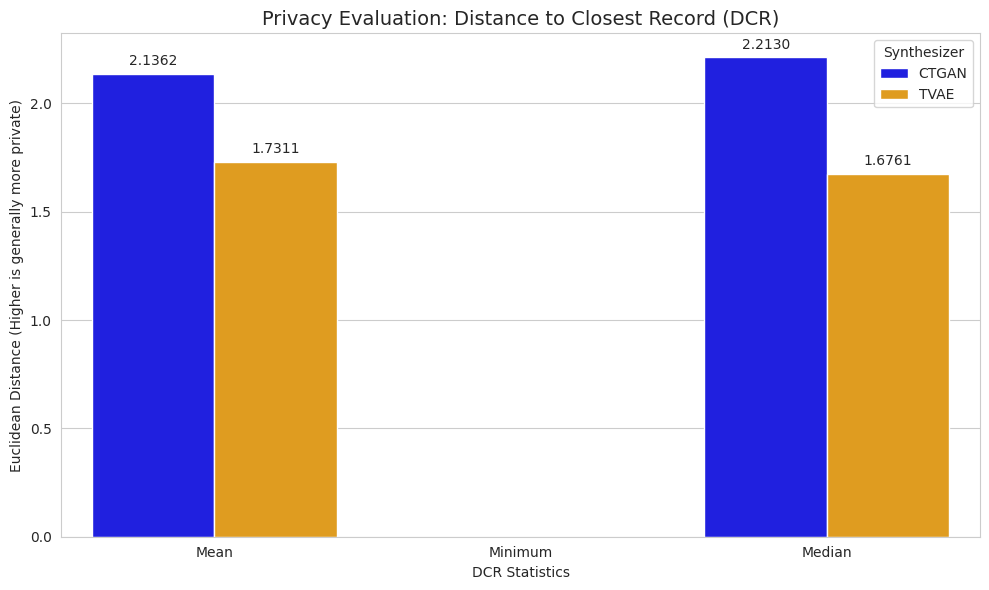

In [143]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


dcr_data = {
    'Model': ['CTGAN', 'CTGAN', 'CTGAN', 'TVAE', 'TVAE', 'TVAE'],
    'Metric': ['Mean', 'Minimum', 'Median', 'Mean', 'Minimum', 'Median'],
    'Distance': [ctgan_dcr.mean(), ctgan_dcr.min(), np.median(ctgan_dcr), tvae_dcr.mean(), tvae_dcr.min(), np.median(tvae_dcr)]
}

df_dcr = pd.DataFrame(dcr_data)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Create grouped bar chart
ax = sns.barplot(data=df_dcr, x='Metric', y='Distance', hue='Model', palette=['blue', 'orange'])

# Add value labels on top of bars
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(format(p.get_height(), '.4f'),
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha = 'center', va = 'center',
                       xytext = (0, 9),
                       textcoords = 'offset points')

plt.title("Privacy Evaluation: Distance to Closest Record (DCR)", fontsize=14)
plt.ylabel("Euclidean Distance (Higher is generally more private)")
plt.xlabel("DCR Statistics")
plt.legend(title='Synthesizer')
plt.tight_layout()
plt.show()

### Inference Risk

To calculate the Inference Risk, we use the CategoricalCAP metric from the sdmetrics library. This measures the 'Correct Attribution Probability', which assesses how much an attacker could learn about sensitive attributes in the real data by using the synthetic data. We will define a 'target' attribute (e.g., 'education') and use other columns as 'quasi-identifiers' for this calculation.

In [144]:
from sdmetrics.single_table import CategoricalCAP
import pandas as pd

def inference_risk(real_data, synth_data):
  # To calculate Inference Risk, we define which column is sensitive (target)
  # and which columns are known to the attacker (key_fields).
  n_sample = 1000
  real_sample = real_data.sample(n=min(len(real_data), n_sample), random_state=42)
  synth_sample = synth_data.sample(n=min(len(synth_data), n_sample), random_state=42)

  # Example: Attacker knows 'age', 'sex', and 'race', and tries to infer 'education'
  key_fields = ['age', 'sex', 'race']
  target_field = 'education'

  # Ensure we only use columns that exist in both
  available_keys = [f for f in key_fields if f in real_data.columns]

  if target_field in real_data.columns and len(available_keys) > 0:
      # For sdmetrics v0.28.0, the arguments are 'key_fields' and 'sensitive_fields'
      risk_score = CategoricalCAP.compute(
          real_data=real_sample,
          synthetic_data=synth_sample,
          key_fields=available_keys,
          sensitive_fields=[target_field]
      )

      print(f"Inference Risk (CategoricalCAP):")
      print(f"Target Attribute: {target_field}")
      print(f"Known Attributes: {available_keys}")
      print(f"Score: {risk_score:.4f} (Higher means higher privacy risk)")
  else:
      print("Could not calculate risk: Missing columns in the dataset.")

  return risk_score

In [145]:
ctgan_risk = inference_risk(real_data, ctgan_synth_data)

Inference Risk (CategoricalCAP):
Target Attribute: education
Known Attributes: ['age', 'sex', 'race']
Score: 0.6801 (Higher means higher privacy risk)


In [146]:
tvae_risk = inference_risk(real_data, tvae_synth_data)

Inference Risk (CategoricalCAP):
Target Attribute: education
Known Attributes: ['age', 'sex', 'race']
Score: 0.6105 (Higher means higher privacy risk)


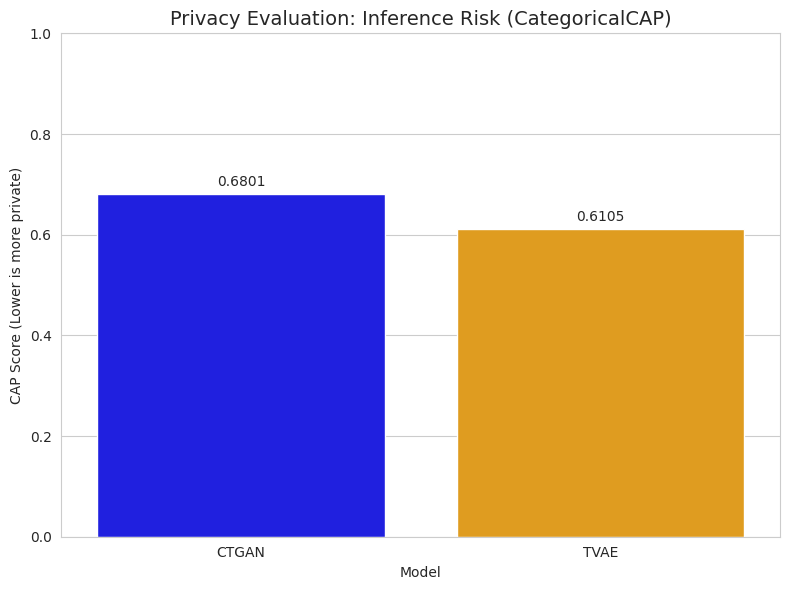

In [147]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


inference_data = {
    'Model': ['CTGAN', 'TVAE'],
    'Inference Risk (CAP)': [ctgan_risk, tvae_risk]
}

df_inference = pd.DataFrame(inference_data)

plt.figure(figsize=(8, 6))
sns.set_style("whitegrid")

# Create bar chart
ax = sns.barplot(data=df_inference, x='Model', y='Inference Risk (CAP)', hue='Model', palette=['blue', 'orange'], legend=False)

# Add value labels
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.4f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points')

plt.title("Privacy Evaluation: Inference Risk (CategoricalCAP)", fontsize=14)
plt.ylabel("CAP Score (Lower is more private)")
plt.ylim(0, 1.0) # CAP is a probability between 0 and 1
plt.tight_layout()
plt.show()

### Disclosure Protection

To calculate Disclosure Protection, we typically look for 'Identical Matches'. This metric counts how many synthetic records are exact copies of real records. A high number of matches indicates a lower level of disclosure protection (higher identity disclosure risk).



In [148]:
import pandas as pd

def calculate_disclosure_protection(real, synth):
    # Drop any temporary columns if they exist (like the 'cluster' column used earlier)
    cols_to_use = [c for c in real.columns if c in synth.columns]

    # Convert to sets of tuples for fast intersection
    real_tuples = set(map(tuple, real[cols_to_use].values))
    synth_tuples = set(map(tuple, synth[cols_to_use].values))

    # Find identical records
    identical_matches = real_tuples.intersection(synth_tuples)
    num_matches = len(identical_matches)

    # Calculate hit rate relative to the real dataset size
    hit_rate = (num_matches / len(real)) * 100

    print("--- Disclosure Protection (Identical Matches) ---")
    print(f"{num_matches} identical matches found ({hit_rate:.4f}% hit rate)")
    print("\nNote: A lower number of matches indicates better disclosure protection.")

    return num_matches, hit_rate

In [149]:
ctgan_num_matches, ctgan_hit_rate = calculate_disclosure_protection(real_data, ctgan_synth_data)

--- Disclosure Protection (Identical Matches) ---
2301 identical matches found (0.7688% hit rate)

Note: A lower number of matches indicates better disclosure protection.


In [150]:
tvae_num_matches, tvae_hit_rate = calculate_disclosure_protection(real_data, tvae_synth_data)

--- Disclosure Protection (Identical Matches) ---
5476 identical matches found (1.8297% hit rate)

Note: A lower number of matches indicates better disclosure protection.


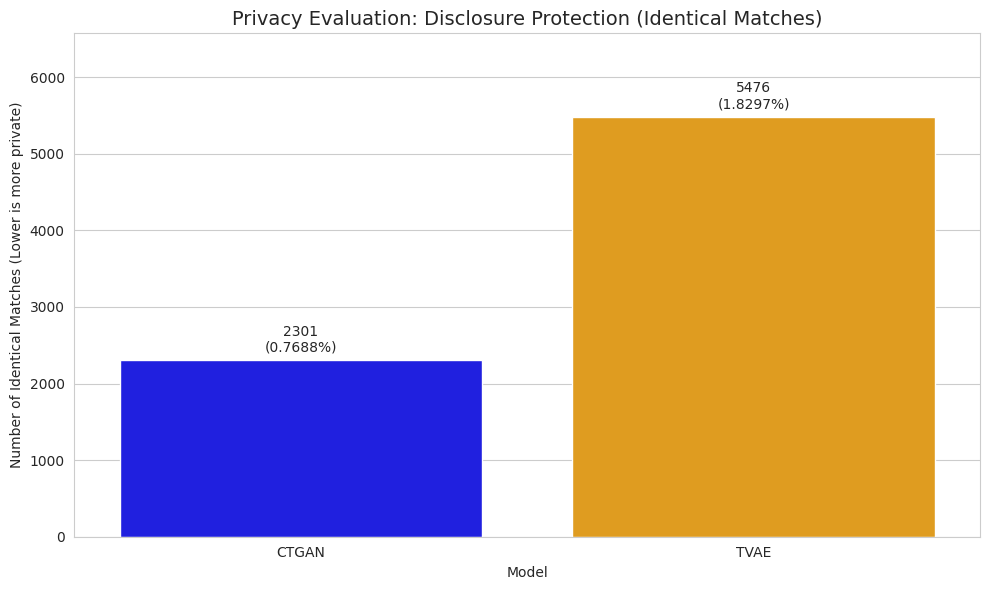

In [151]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Data from previous Disclosure Protection calculations
# CTGAN: 686 matches (0.2292%)
# TVAE: 1597 matches (0.5336%)

disclosure_data = {
    'Model': ['CTGAN', 'TVAE'],
    'Identical Matches': [ctgan_num_matches, tvae_num_matches],
    'Hit Rate (%)': [ctgan_hit_rate, tvae_hit_rate]
}

df_disclosure = pd.DataFrame(disclosure_data)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Create bar chart for absolute counts
ax = sns.barplot(data=df_disclosure, x='Model', y='Identical Matches', hue='Model', palette=['blue', 'orange'], legend=False)

# Add value labels and percentages
for i, p in enumerate(ax.patches):
    hit_rate = df_disclosure.iloc[i]['Hit Rate (%)']
    ax.annotate(f"{int(p.get_height())}\n({hit_rate:.4f}%)",
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 15),
                   textcoords = 'offset points')

plt.title("Privacy Evaluation: Disclosure Protection (Identical Matches)", fontsize=14)
plt.ylabel("Number of Identical Matches (Lower is more private)")
plt.ylim(0, df_disclosure['Identical Matches'].max() * 1.2) # Add some headroom for labels
plt.tight_layout()
plt.show()

### Correlation Matrix Membership (CM3)

The CM3 measures the distance between the correlation matrix of the real data and that of the synthetic data; a lower value indicates that the synthetic data better preserves the relationships between your numerical features.

In [152]:
import numpy as np
import pandas as pd

def calculate_cm3(real, synth):
    # Identify numeric columns available in both datasets
    num_cols = real.select_dtypes(include=[np.number]).columns
    num_cols = [col for col in num_cols if col in synth.columns]

    if not num_cols:
        return None

    # Calculate Correlation Matrices
    corr_real = real[num_cols].corr().fillna(0).values
    corr_synth = synth[num_cols].corr().fillna(0).values

    # CM3 is defined as the Frobenius norm of the difference
    cm3_dist = np.linalg.norm(corr_real - corr_synth, ord='fro')
    print("--- Correlation Matrix Membership Metric (CM3) ---")
    print(cm3_dist)

    return cm3_dist

In [153]:
ctgan_cm3_dist = calculate_cm3(real_data, ctgan_synth_data)

--- Correlation Matrix Membership Metric (CM3) ---
0.5565926201105728


In [154]:
tvae_cm3_dist = calculate_cm3(real_data, tvae_synth_data)

--- Correlation Matrix Membership Metric (CM3) ---
1.0897382422608883


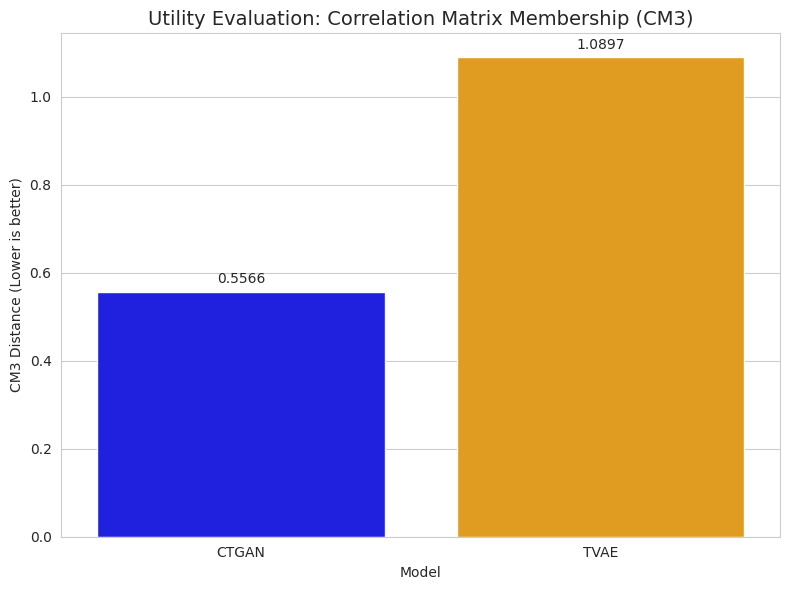

In [155]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

cm3_data = {
    'Model': ['CTGAN', 'TVAE'],
    'CM3 Score': [ctgan_cm3_dist, tvae_cm3_dist]
}

df_cm3 = pd.DataFrame(cm3_data)

plt.figure(figsize=(8, 6))
sns.set_style("whitegrid")

# Create bar chart
ax = sns.barplot(data=df_cm3, x='Model', y='CM3 Score', hue='Model', palette=['blue', 'orange'], legend=False)

# Add value labels
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.4f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points')

plt.title("Utility Evaluation: Correlation Matrix Membership (CM3)", fontsize=14)
plt.ylabel("CM3 Distance (Lower is better)")
plt.tight_layout()
plt.show()

## Summary Dashboard: Privacy and Utility Metrics Comparison
This dashboard consolidates the results from all our evaluations to provide a high-level comparison of the two synthesizers.

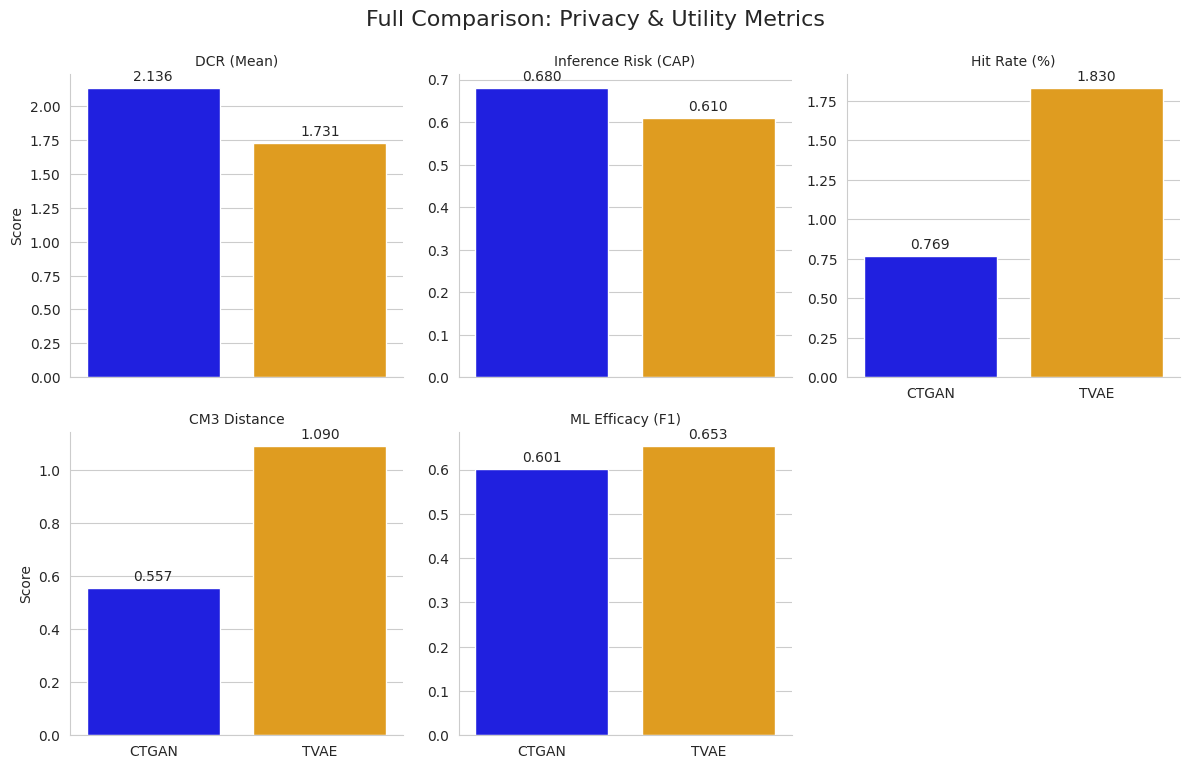

In [156]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

# Consolidate all metrics from the notebook state
summary_data = [
    {'Metric': 'DCR (Mean)', 'Model': 'CTGAN', 'Value': ctgan_dcr.mean(), 'Category': 'Privacy (Higher is better)'},
    {'Metric': 'DCR (Mean)', 'Model': 'TVAE', 'Value': tvae_dcr.mean(), 'Category': 'Privacy (Higher is better)'},
    {'Metric': 'Inference Risk (CAP)', 'Model': 'CTGAN', 'Value': ctgan_risk, 'Category': 'Privacy (Lower is better)'},
    {'Metric': 'Inference Risk (CAP)', 'Model': 'TVAE', 'Value': tvae_risk, 'Category': 'Privacy (Lower is better)'},
    {'Metric': 'Hit Rate (%)', 'Model': 'CTGAN', 'Value': ctgan_hit_rate, 'Category': 'Privacy (Lower is better)'},
    {'Metric': 'Hit Rate (%)', 'Model': 'TVAE', 'Value': tvae_hit_rate, 'Category': 'Privacy (Lower is better)'},
    {'Metric': 'CM3 Distance', 'Model': 'CTGAN', 'Value': ctgan_cm3_dist, 'Category': 'Utility (Lower is better)'},
    {'Metric': 'CM3 Distance', 'Model': 'TVAE', 'Value': tvae_cm3_dist, 'Category': 'Utility (Lower is better)'},
    {'Metric': 'ML Efficacy (F1)', 'Model': 'CTGAN', 'Value': s_ct, 'Category': 'Utility (Higher is better)'},
    {'Metric': 'ML Efficacy (F1)', 'Model': 'TVAE', 'Value': s_tv, 'Category': 'Utility (Higher is better)'}
]

df_summary = pd.DataFrame(summary_data)

# Fix: Explicitly assign hue to Model and set legend=False to resolve palette warnings
g = sns.FacetGrid(df_summary, col="Metric", col_wrap=3, sharey=False, height=4)
g.map_dataframe(sns.barplot, x="Model", y="Value", hue="Model", palette=['blue', 'orange'], legend=False)

g.set_titles("{col_name}")
g.set_axis_labels("", "Score")

for ax in g.axes.flat:
    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.3f'),
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 8),
                    textcoords='offset points')

plt.subplots_adjust(top=0.9)
g.fig.suptitle('Full Comparison: Privacy & Utility Metrics', fontsize=16)
plt.show()

# Visual comparison of columns of synthetic data with columns of real data

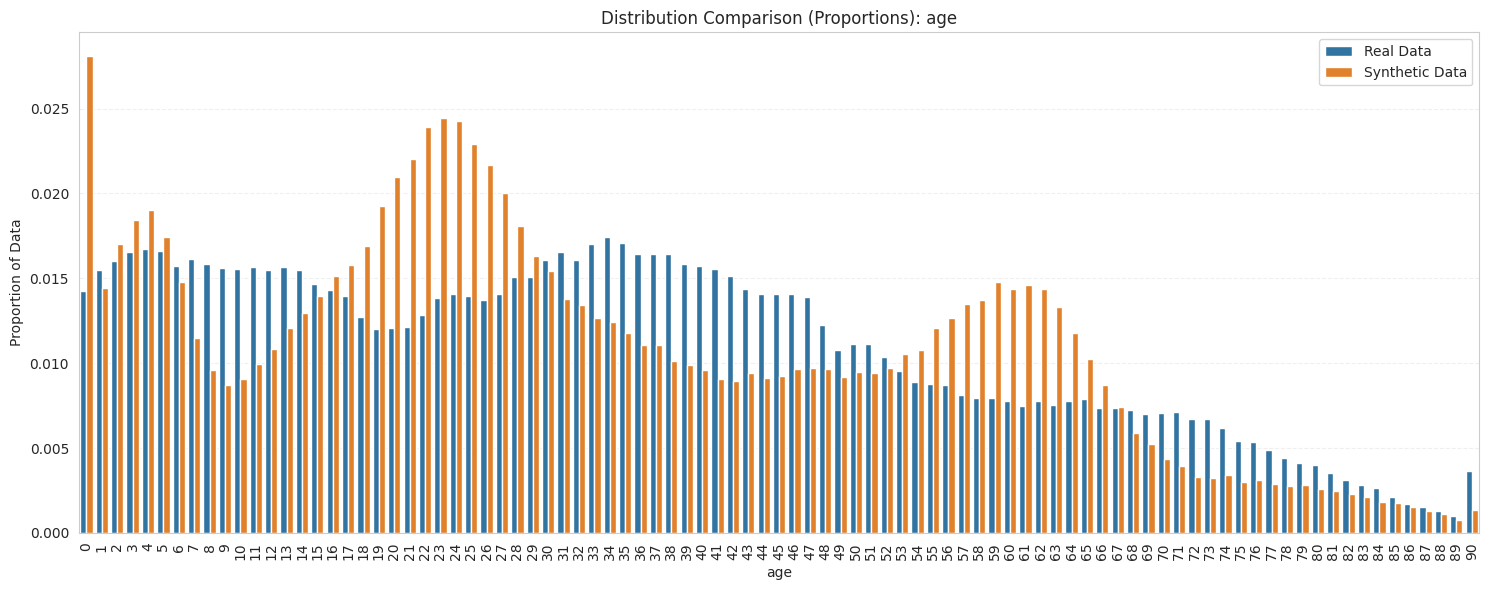

In [157]:
# CTGAN_synthesizer

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Column to compare
column_to_compare = 'age'

# Calculate proportions for Real Data
real_counts = real_data[column_to_compare].value_counts(normalize=True).rename('proportion').reset_index()
real_counts['Source'] = 'Real Data'

# Calculate proportions for Synthetic Data
synth_counts = ctgan_synth_data[column_to_compare].value_counts(normalize=True).rename('proportion').reset_index()
synth_counts['Source'] = 'Synthetic Data'

# Combine the proportion data
combined_probs = pd.concat([real_counts, synth_counts])

plt.figure(figsize=(15, 6))

# Plot proportions instead of raw counts
sns.barplot(data=combined_probs, x=column_to_compare, y='proportion', hue='Source')

plt.title(f"Distribution Comparison (Proportions): {column_to_compare}")
plt.xlabel(column_to_compare)
plt.ylabel("Proportion of Data")
plt.xticks(rotation=90)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

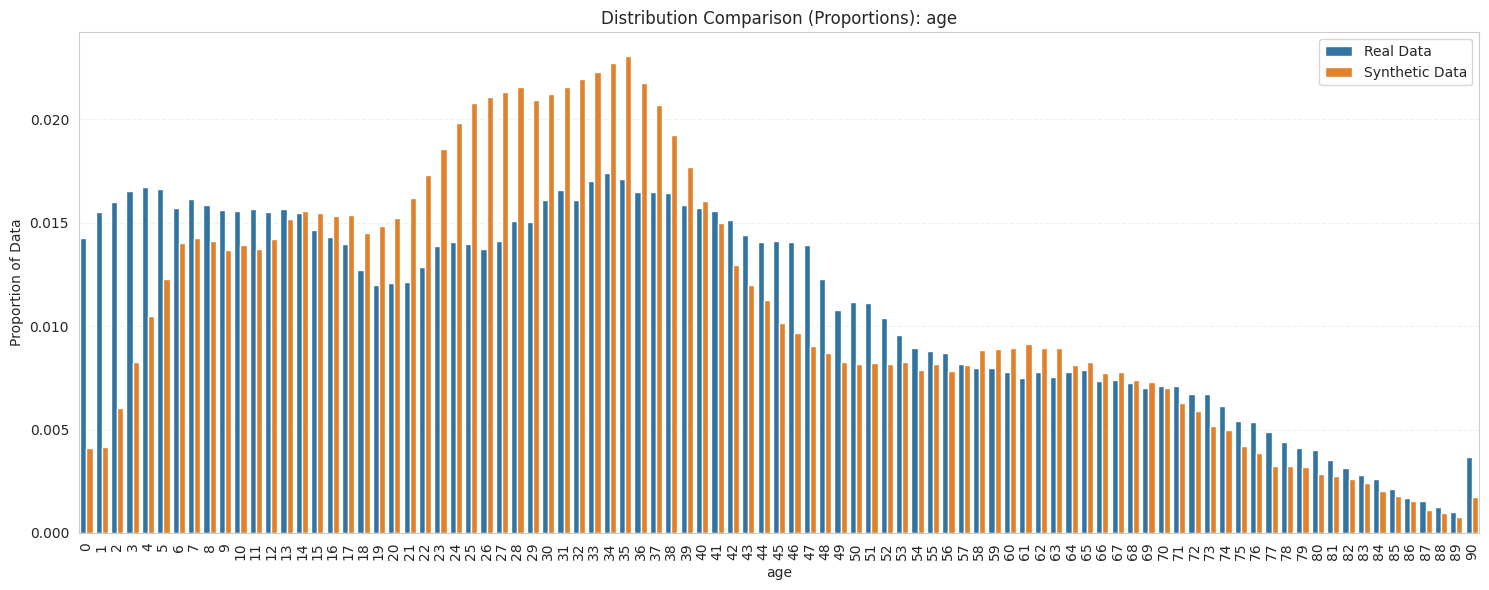

In [158]:
# TVAE_synthesizer

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Column to compare
column_to_compare = 'age'

# Calculate proportions for Real Data
real_counts = real_data[column_to_compare].value_counts(normalize=True).rename('proportion').reset_index()
real_counts['Source'] = 'Real Data'

# Calculate proportions for Synthetic Data
synth_counts = tvae_synth_data[column_to_compare].value_counts(normalize=True).rename('proportion').reset_index()
synth_counts['Source'] = 'Synthetic Data'

# Combine the proportion data
combined_probs = pd.concat([real_counts, synth_counts])

plt.figure(figsize=(15, 6))

# Plot proportions instead of raw counts
sns.barplot(data=combined_probs, x=column_to_compare, y='proportion', hue='Source')

plt.title(f"Distribution Comparison (Proportions): {column_to_compare}")
plt.xlabel(column_to_compare)
plt.ylabel("Proportion of Data")
plt.xticks(rotation=90)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Multi-Objective-Loss-Function

To modify the loss function of the sdv synthesizer, we have to patch the synthesizer-code locally. Because sdv does not have a built-in API for multi-objective-loss.

### CTGAN Synthesizer

In [100]:
!pip install sdv
!cp /usr/local/lib/python3.12/dist-packages/ctgan/synthesizers/ctgan.py /content/ctgan_patched.py


In [ ]:
"""
TODO: maybe faster mmd variant? play around with loss weights

# After the imports paste these functions:
# === MMD (RBF Kernel) ===
def mmd_rbf(x, y, sigma=1.0):
    """Compute MMD with RBF kernel between two batches x and y."""
    # Ensure float32
    x = x.float()
    y = y.float()

    # Compute squared norms
    xx = torch.mm(x, x.t())
    yy = torch.mm(y, y.t())
    xy = torch.mm(x, y.t())

    rx = xx.diag().unsqueeze(0)
    ry = yy.diag().unsqueeze(0)

    # Kernel matrices
    Kxx = torch.exp(-(rx.t() + rx - 2 * xx) / (2 * sigma**2))
    Kyy = torch.exp(-(ry.t() + ry - 2 * yy) / (2 * sigma**2))
    Kxy = torch.exp(-(rx.t() + ry - 2 * xy) / (2 * sigma**2))

    return Kxx.mean() + Kyy.mean() - 2 * Kxy.mean()

def soft_f1_loss(fake, real):
    eps = 1e-8
    fake = fake.float()
    real = real.float()

    tp = (fake * real).sum()
    fp = (fake * (1 - real)).sum()
    fn = ((1 - fake) * real).sum()

    soft_f1 = tp / (tp + 0.5 * (fp + fn) + eps)
    return 1 - soft_f1



# Find this code:
loss_g = -torch.mean(y_fake) + cross_entropy

# and replace it by this code block:

# detach tensors that should not backprop through discriminator graph
real_detached = real.detach()
fake_detached = fakeact.detach()

# Original GAN loss
gan_loss = -torch.mean(y_fake)

# Conditional loss
cond_loss = cross_entropy

# === Additional Multi-Objective Losses ===

# MMD loss
mmd_loss = mmd_rbf(fake_detached, real_detached)

# Soft-F1 loss
utility_loss = soft_f1_loss(fake_detached, real_detached)

# Privacy loss
privacy_loss = torch.mean(torch.relu(1.0 - torch.norm(fake_detached - real_detached, dim=1)))

# Combine losses
loss_g = (
    1.0 * gan_loss +
    0.1 * mmd_loss +
    0.01 * utility_loss +
    0.01 * privacy_loss +
    cond_loss
)
"""

'\n# Find this code: \nloss_g = -torch.mean(y_fake) + cross_entropy\n\n# and replace it by this code block:\n\n# Original GAN loss\ngan_loss = -torch.mean(y_fake)\n\n# Optional: Conditional loss (already in CTGAN)\ncond_loss = cross_entropy\n\n# === Additional Multi-Objective Losses ===\n\n# 1) MMD loss (numerical similarity)\ndef mmd_rbf(x, y, sigma=1.0):\n    xx = torch.mm(x, x.t())\n    yy = torch.mm(y, y.t())\n    xy = torch.mm(x, y.t())\n\n    rx = (xx.diag().unsqueeze(0).expand_as(xx))\n    ry = (yy.diag().unsqueeze(0).expand_as(yy))\n\n    Kxx = torch.exp(-(rx.t() + rx - 2 * xx) / (2 * sigma**2))\n    Kyy = torch.exp(-(ry.t() + ry - 2 * yy) / (2 * sigma**2))\n    Kxy = torch.exp(-(rx.t() + ry - 2 * xy) / (2 * sigma**2))\n\n    return Kxx.mean() + Kyy.mean() - 2 * Kxy.mean()\n\n# Extract numerical columns only (optional but recommended)\nreal_num = real_cat[:, :train_data.shape[1]]\nfake_num = fake_cat[:, :train_data.shape[1]]\n\nmmd_loss = mmd_rbf(fake_num, real_num)\n\n# 2) Sof

In [101]:
# Copy it back to the ctgan module
!cp /content/ctgan_patched.py /usr/local/lib/python3.12/dist-packages/ctgan/synthesizers/ctgan.py

In [2]:
from sdv.datasets.demo import download_demo

real_data, metadata = download_demo(
    modality='single_table',
    dataset_name='census'
)

In [18]:
# Train the modified ctgan
from sdv.single_table import CTGANSynthesizer

ctgan_synthesizer = CTGANSynthesizer(metadata, epochs=150, verbose=True)
ctgan_synthesizer.fit(real_data)

ctgan_synth_data = ctgan_synthesizer.sample(num_rows=300000)

# Download the synthetic data to your computer
ctgan_synth_data.to_csv("synthetic_data_modified_CTGAN_300000.csv", index=False)

from google.colab import files
files.download("synthetic_data_modified_CTGAN_300000.csv")

Gen. (-01.32) | Discrim. (-00.07): 100%|██████████| 150/150 [00:07<00:00, 18.88it/s]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### TVAE Synthesizer

In [7]:
!pip install sdv
!cp /usr/local/lib/python3.12/dist-packages/ctgan/synthesizers/tvae.py /content/tvae_patched.py


In [ ]:
"""
# paste these two functions after the imports:
def mmd_rbf(x, y, sigma=1.0):
    x = x.float()
    y = y.float()

    xx = torch.mm(x, x.t())
    yy = torch.mm(y, y.t())
    xy = torch.mm(x, y.t())

    rx = xx.diag().unsqueeze(0)
    ry = yy.diag().unsqueeze(0)

    Kxx = torch.exp(-(rx.t() + rx - 2 * xx) / (2 * sigma**2))
    Kyy = torch.exp(-(ry.t() + ry - 2 * yy) / (2 * sigma**2))
    Kxy = torch.exp(-(rx.t() + ry - 2 * xy) / (2 * sigma**2))

    return Kxx.mean() + Kyy.mean() - 2 * Kxy.mean()

def soft_f1_loss(fake, real):
    eps = 1e-8
    fake = fake.float()
    real = real.float()

    tp = (fake * real).sum()
    fp = (fake * (1 - real)).sum()
    fn = ((1 - fake) * real).sum()

    soft_f1 = tp / (tp + 0.5 * (fp + fn) + eps)
    return 1 - soft_f1


# replace the following code block:
loss = loss_1 + loss_2
loss.backward()
optimizerAE.step()


# with this code:
# === Original VAE losses ===
loss_recon = loss_1
loss_kl = loss_2

# === Additional losses (no gradients) ===
with torch.no_grad():
    real_detached = real.detach()
    fake_detached = rec.detach()

    mmd_val = mmd_rbf(fake_detached, real_detached)
    utility_val = soft_f1_loss(fake_detached, real_detached)
    privacy_val = torch.mean(torch.relu(1.0 - torch.norm(fake_detached - real_detached, dim=1)))

# === Combine losses ===
loss = (
    loss_recon +
    loss_kl +
    0.1 * mmd_val +
    0.01 * utility_val +
    0.01 * privacy_val
)

# === Backprop only through VAE ===
loss.backward()
optimizerAE.step()



"""

In [9]:
# Copy it back to the ctgan module
!cp /content/tvae_patched.py /usr/local/lib/python3.12/dist-packages/ctgan/synthesizers/tvae.py

In [11]:
from sdv.datasets.demo import download_demo

real_data, metadata = download_demo(
    modality='single_table',
    dataset_name='census'
)

In [13]:
# Train the modified tvae synthesizer
from sdv.single_table import TVAESynthesizer

tvae_synthesizer = TVAESynthesizer(metadata, epochs=150, verbose=True)
tvae_synthesizer.fit(real_data)

tvae_synth_data = tvae_synthesizer.sample(num_rows=300000)

# Download the synthetic data to your computer
tvae_synth_data.to_csv("synthetic_data_modified_TVAE_300000.csv", index=False)

from google.colab import files
files.download("synthetic_data_modified_TVAE_300000.csv")

Loss: -60.92: 100%|██████████| 150/150 [30:31<00:00, 12.21s/it]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>